# Pain Prediction Analysis - Synthetic 200p (SVM Version)
**Dataset**: `synthetic_200p_accuracy70_80.csv`

This notebook implements a Support Vector Machine (SVM) pipeline for pain scale prediction:
1. **EDA**: Visualizing distributions and correlations.
2. **Feature Engineering**: Vector magnitudes, stress index, and temp variations.
3. **Model Training**: SVM Classifier (RBF Kernel) with sampling for efficiency.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

# Load the dataset
df = pd.read_csv('synthetic_200p_accuracy70_80.csv')

# Ignore person_ID as it is unnecessary for the model
if 'person_ID' in df.columns:
    df = df.drop(columns=['person_ID'])

print(f"Dataset Loaded: {df.shape[0]} samples, {df.shape[1]} features.")
display(df.head())

Dataset Loaded: 96000 samples, 8 features.


,acc_x,acc_y,acc_z,eda,bvp,hr,temp,pain_scale
0,0.2751,-0.0464,0.3049,0.7395,99.24,67.6,33.94,5
1,0.2428,-0.1161,0.3641,0.7793,103.24,68.3,33.95,5
2,0.0146,-0.1479,0.6552,0.8581,103.08,68.1,33.91,5
3,-0.0806,-0.2144,0.6631,0.8881,104.12,66.6,33.94,5
4,-0.0808,-0.1754,0.5448,0.7786,107.05,66.8,33.95,5


## 1. Exploratory Data Analysis (EDA)

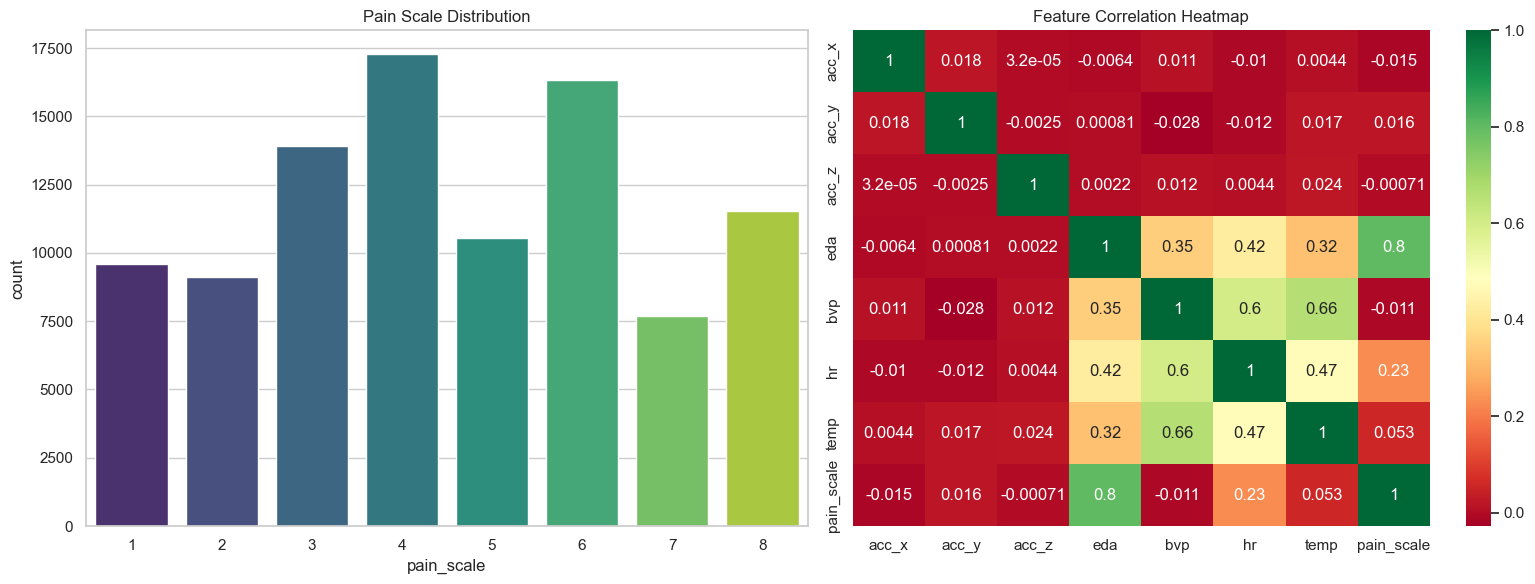

In [2]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Pain Scale Distribution
target_col = 'pain_scale'
sns.countplot(data=df, x=target_col, palette='viridis', ax=ax[0])
ax[0].set_title('Pain Scale Distribution')

# Correlation Matrix
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='RdYlGn', ax=ax[1])
ax[1].set_title('Feature Correlation Heatmap')

plt.tight_layout()
plt.show()

## 2. Feature Engineering

In [3]:
def engineer_features(data):
    df_fe = data.copy()
    
    # 1. Acceleration Magnitude
    df_fe['acc_magnitude'] = np.sqrt(df_fe['acc_x']**2 + df_fe['acc_y']**2 + df_fe['acc_z']**2)
    
    # 2. Stress Index interaction (EDA * HR)
    df_fe['stress_index'] = df_fe['eda'] * df_fe['hr']
    
    # 3. Temp Delta
    df_fe['temp_delta'] = np.abs(df_fe['temp'] - df_fe['temp'].mean())
    
    return df_fe

print("Performing advanced feature engineering...")
df_proc = engineer_features(df)
print(f"Feature space expanded: {df_proc.shape[1]} columns.")

Performing advanced feature engineering...
Feature space expanded: 11 columns.


## 3. Machine Learning: Support Vector Machine (SVM)

In [4]:
X = df_proc.drop(columns=['pain_scale'])
y = df_proc['pain_scale']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# SVM can be slow on large datasets, using a stratified subset for training
X_train_sub, _, y_train_sub, _ = train_test_split(X_train, y_train, train_size=10000, random_state=42, stratify=y_train)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sub)
X_test_scaled = scaler.transform(X_test)

print("Training SVM Classifier (RBF Kernel)...")
svm = SVC(kernel='rbf', C=1.0, probability=True, random_state=42)
svm.fit(X_train_scaled, y_train_sub)

y_preds = svm.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_preds)

print(f"\nSystem Validation Accuracy: {accuracy*100:.2f}%")

Training SVM Classifier (RBF Kernel)...

System Validation Accuracy: 48.66%


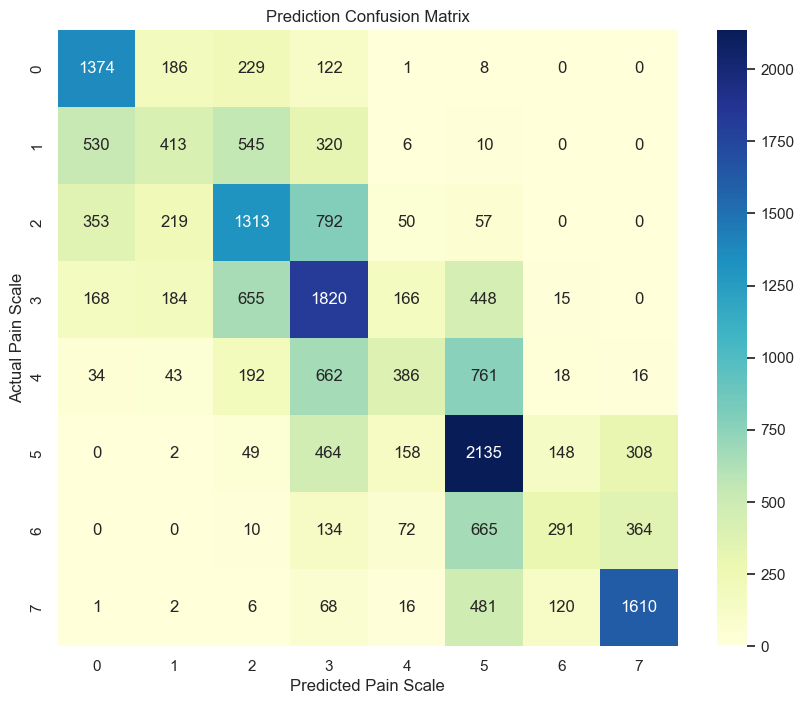

Full Metrics Report:
              precision    recall  f1-score   support

           1       0.56      0.72      0.63      1920
           2       0.39      0.23      0.29      1824
           3       0.44      0.47      0.45      2784
           4       0.42      0.53      0.46      3456
           5       0.45      0.18      0.26      2112
           6       0.47      0.65      0.55      3264
           7       0.49      0.19      0.27      1536
           8       0.70      0.70      0.70      2304

    accuracy                           0.49     19200
   macro avg       0.49      0.46      0.45     19200
weighted avg       0.48      0.49      0.47     19200



In [5]:
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Prediction Confusion Matrix')
plt.ylabel('Actual Pain Scale')
plt.xlabel('Predicted Pain Scale')
plt.show()

print("Full Metrics Report:")
print(classification_report(y_test, y_preds))